# Cruise, for a fixed wing

A wing wants endurance, and endurance is electrical watts per airspeed -
so the question this notebook asks its motor is not "how fast" but
**what does each cruise rpm cost**. The drive reports its own dq volts
and amps; `P = 1.5 (vd id + vq iq)` is the electrical power in the
amplitude-invariant frame, the same convention the firmware computes in.

In [1]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))

from coaxial import Coaxial63100

SIMULATED = True                    # False at the bench
PORT = 'COM4'

rig = Coaxial63100(port=PORT, simulated_device=SIMULATED,
                   power_afe=False).open()
rig.drive.source('model')           # the virtual rotor; 'adc' at the bench
rig.gates.arm(bypass_sto=True, ignore_interlock=True)
print(rig)
BLUE, RED, GREY = '#1f4e79', '#c0392b', '#95a5a6'
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.15})


<Coaxial63100 Simulated SIMULATED>


In [2]:
K_PROP = 1.1e-6           # the cruise prop's law, T = K w^2

points = []
with rig.motion.velocity(amps=4.5, hz=2.5, load_k=K_PROP) as esc:
    def drag(v):
        w = v.bus.w
        rig.drive.model_param(load=K_PROP * w * abs(w))
    for target in (1400, 1800, 2200, 2600, 3000):
        esc.rpm(target, seconds=2.0, watch=drag)
        st = rig.drive.state()
        watts = 1.5 * (st['vd'] * st['id'] + st['vq'] * st['iq'])
        points.append((esc.rpm_now, watts, st['iq']))
        print('%4.0f rpm  %6.2f W  iq %.2f A' % points[-1])
    esc.stop(1.5)

1400 rpm    3.70 W  iq 0.48 A


1800 rpm    7.77 W  iq 0.78 A


2200 rpm   14.08 W  iq 1.16 A


2600 rpm   23.14 W  iq 1.61 A


3000 rpm   35.43 W  iq 2.13 A


the gap between the curves is copper, iron and the inverter -
the loss budget loss_calculation.ipynb itemises


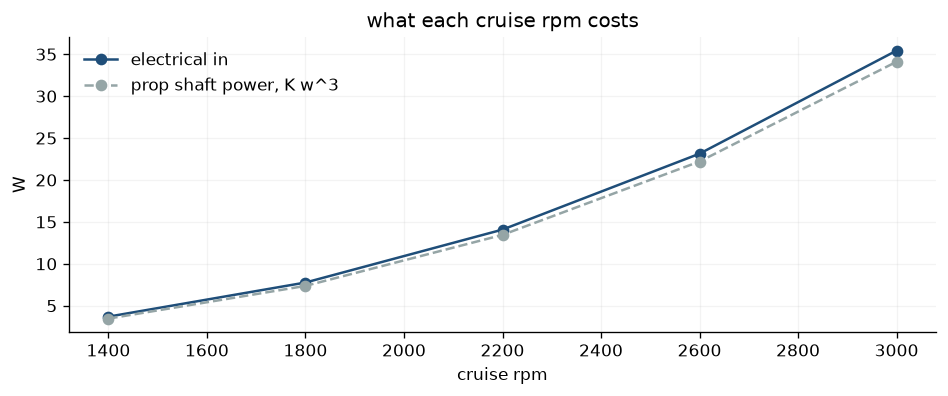

In [3]:
rpm, watts, iq = np.array(points).T
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(rpm, watts, 'o-', color=BLUE, label='electrical in')
ax.plot(rpm, K_PROP * (rpm * 2 * math.pi / 60) ** 3, 'o--', color=GREY,
        label='prop shaft power, K w^3')
ax.set(xlabel='cruise rpm', ylabel='W', title='what each cruise rpm costs')
ax.legend(frameon=False)
fig.tight_layout()
print('the gap between the curves is copper, iron and the inverter -')
print('the loss budget loss_calculation.ipynb itemises')

## Reading it as an airframe

Divide the electrical curve by the airspeed each rpm buys on YOUR prop
and wing and the minimum of W per m/s is the max-range throttle; W alone
bottoms at the max-endurance one. Both divisions need the propeller's
chart - the board's half of the bargain is the honest watts above, and
at the bench they come from a spanned DC link instead of a model.